# Statistical Analysis of the Iris Dataset

**Project:** Statistics Superstars – Data Detective: Exploring Real-World Distributions

**Dataset:** Iris Flower Dataset

This notebook performs statistical analysis on the Iris dataset, including descriptive statistics, distribution analysis, confidence intervals, hypothesis testing, and one-way ANOVA.

In [27]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add the project root folder so we can import from src
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.statistics import (
    descriptive_stats,
    fit_distribution,
    bootstrap_ci,
    hypothesis_test,
    anova_test
)

In [28]:
data_path = project_root / "data" / "processed" / "iris_clean.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [29]:
numeric_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

print("Numerical variables:")
print(numeric_columns)

Numerical variables:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


## Descriptive Statistics Using the Custom Function

The custom `descriptive_stats()` function is applied to each numerical variable to calculate measures of central tendency, variability, skewness, and kurtosis.

In [30]:
descriptive_results = {}

for column in numeric_columns:
    descriptive_results[column] = descriptive_stats(
        df[column].tolist()
    )

descriptive_results

{'sepal_length': {'mean': 5.843333333333334,
  'median': 5.8,
  'mode': 5.0,
  'std': 0.828066127977863,
  'variance': 0.6856935123042507,
  'range': 3.6000000000000005,
  'iqr': 1.3000000000000007,
  'skewness': 0.3117530585022963,
  'kurtosis': -0.5735679489249765},
 'sepal_width': {'mean': 3.0540000000000003,
  'median': 3.0,
  'mode': 3.0,
  'std': 0.4335943113621737,
  'variance': 0.1880040268456376,
  'range': 2.4000000000000004,
  'iqr': 0.5,
  'skewness': 0.330702812773315,
  'kurtosis': 0.24144329938318343},
 'petal_length': {'mean': 3.758666666666666,
  'median': 4.35,
  'mode': 1.5,
  'std': 1.7644204199522626,
  'variance': 3.113179418344519,
  'range': 5.9,
  'iqr': 3.4999999999999996,
  'skewness': -0.2717119501716386,
  'kurtosis': -1.3953593021397128},
 'petal_width': {'mean': 1.1986666666666668,
  'median': 1.3,
  'mode': 0.2,
  'std': 0.7631607417008411,
  'variance': 0.582414317673378,
  'range': 2.4,
  'iqr': 1.5,
  'skewness': -0.10394366626751729,
  'kurtosis': -1

In [31]:
descriptive_table = pd.DataFrame(
    descriptive_results
).T

descriptive_table.round(3)

,mean,median,mode,std,variance,range,iqr,skewness,kurtosis
sepal_length,5.843,5.80,5.0,0.828,0.686,3.6,1.3,0.312,-0.574
sepal_width,3.054,3.00,3.0,0.434,0.188,2.4,0.5,0.331,0.241
petal_length,3.759,4.35,1.5,1.764,3.113,5.9,3.5,-0.272,-1.395
petal_width,1.199,1.30,0.2,0.763,0.582,2.4,1.5,-0.104,-1.335


## Distribution and Normality Analysis

Normality is examined for each numerical variable using a fitted normal distribution and the Kolmogorov–Smirnov goodness-of-fit test.

In [32]:
normality_results = {}

for column in numeric_columns:
    result = fit_distribution(
        df[column].tolist(),
        "normal"
    )

    normality_results[column] = result

normality_results

{'sepal_length': {'params': (5.843333333333334, 0.8253012917851409),
  'ks_statistic': 0.08945440179507252,
  'p_value': 0.17058360931631134},
 'sepal_width': {'params': (3.0540000000000003, 0.4321465800705435),
  'ks_statistic': 0.10305477506469923,
  'p_value': 0.07694369991172811},
 'petal_length': {'params': (3.758666666666666, 1.7585291834055212),
  'ks_statistic': 0.19913533995975097,
  'p_value': 1.0900352050591725e-05},
 'petal_width': {'params': (1.1986666666666668, 0.7606126185881716),
  'ks_statistic': 0.17314802094207016,
  'p_value': 0.0002107783722554333}}

In [33]:
normality_table = pd.DataFrame({
    column: {
        "Mean": normality_results[column]["params"][0],
        "Std Dev": normality_results[column]["params"][1],
        "KS Statistic": normality_results[column]["ks_statistic"],
        "P-Value": normality_results[column]["p_value"]
    }
    for column in numeric_columns
}).T

normality_table.round(4)

,Mean,Std Dev,KS Statistic,P-Value
sepal_length,5.8433,0.8253,0.0895,0.1706
sepal_width,3.0540,0.4321,0.1031,0.0769
petal_length,3.7587,1.7585,0.1991,0.0000
petal_width,1.1987,0.7606,0.1731,0.0002


### Normality Interpretation

Using a significance level of 0.05:

- Sepal length has a p-value of 0.1706, so there is not enough evidence to reject the assumption of normality.
- Sepal width has a p-value of 0.0769, so there is also not enough evidence to reject the assumption of normality.
- Petal length has a p-value below 0.05, providing evidence that its overall distribution is not normal.
- Petal width also has a p-value below 0.05, providing evidence that its overall distribution is not normal.
- The non-normality of the petal measurements may be influenced by combining three Iris species with distinctly different petal sizes.

## 95% Bootstrap Confidence Intervals

Bootstrap resampling is used to estimate 95% confidence intervals for the mean of each numerical Iris measurement.

In [34]:
confidence_results = {}

for column in numeric_columns:
    lower, upper = bootstrap_ci(
        df[column].tolist(),
        np.mean,
        n_bootstrap=10000,
        confidence=0.95
    )

    confidence_results[column] = {
        "Sample Mean": df[column].mean(),
        "Lower 95% CI": lower,
        "Upper 95% CI": upper
    }

confidence_table = pd.DataFrame(confidence_results).T

confidence_table.round(3)

,Sample Mean,Lower 95% CI,Upper 95% CI
sepal_length,5.843,5.712,5.974
sepal_width,3.054,2.985,3.124
petal_length,3.759,3.477,4.033
petal_width,1.199,1.077,1.317


### Confidence Interval Interpretation

Using 10,000 bootstrap samples and a 95% confidence level:

- The estimated mean sepal length is 5.843 cm, with a 95% confidence interval from 5.712 cm to 5.974 cm.
- The estimated mean sepal width is 3.054 cm, with a 95% confidence interval from 2.985 cm to 3.124 cm.
- The estimated mean petal length is 3.759 cm, with a 95% confidence interval from 3.477 cm to 4.033 cm.
- The estimated mean petal width is 1.199 cm, with a 95% confidence interval from 1.077 cm to 1.317 cm.

The petal length confidence interval is wider than the other intervals, which is consistent with the larger variability observed earlier in petal length measurements.

## Hypothesis Testing: Petal Length Between Setosa and Versicolor

We test whether the mean petal length differs significantly between Iris setosa and Iris versicolor.

**Null hypothesis (H₀):** The mean petal length of setosa is equal to the mean petal length of versicolor.

**Alternative hypothesis (H₁):** The mean petal length of setosa is different from the mean petal length of versicolor.

A significance level of α = 0.05 is used.

In [35]:
setosa_petal_length = df[
    df["species"] == "setosa"
]["petal_length"].tolist()

versicolor_petal_length = df[
    df["species"] == "versicolor"
]["petal_length"].tolist()

ttest_result = hypothesis_test(
    setosa_petal_length,
    versicolor_petal_length,
    test_type="t-test"
)

ttest_result

{'test_type': 't-test',
 'statistic': -39.46866259397271,
 'p_value': 1.0572100300603536e-45}

In [36]:
print("Setosa mean petal length:",
      round(np.mean(setosa_petal_length), 3))

print("Versicolor mean petal length:",
      round(np.mean(versicolor_petal_length), 3))

print("T-statistic:",
      round(ttest_result["statistic"], 4))

print("P-value:",
      ttest_result["p_value"])

Setosa mean petal length: 1.464
Versicolor mean petal length: 4.26
T-statistic: -39.4687
P-value: 1.0572100300603536e-45


### T-Test Interpretation

The mean petal length of Setosa is 1.464 cm, while the mean petal length of Versicolor is 4.260 cm.

The Welch two-sample t-test produced a t-statistic of -39.4687 and a p-value of approximately 1.06 × 10⁻⁴⁵.

Since the p-value is much smaller than the significance level of 0.05, we reject the null hypothesis.

Therefore, there is statistically significant evidence that the mean petal length differs between Iris setosa and Iris versicolor.

## One-Way ANOVA: Petal Length Across Iris Species

A one-way ANOVA is used to test whether mean petal length differs among Setosa, Versicolor, and Virginica.

**Null hypothesis (H₀):** The mean petal length is equal across all three Iris species.

**Alternative hypothesis (H₁):** At least one species has a different mean petal length.

A significance level of α = 0.05 is used.

In [37]:
setosa = df[
    df["species"] == "setosa"
]["petal_length"].tolist()

versicolor = df[
    df["species"] == "versicolor"
]["petal_length"].tolist()

virginica = df[
    df["species"] == "virginica"
]["petal_length"].tolist()

anova_result = anova_test(
    setosa,
    versicolor,
    virginica
)

anova_result

{'f_statistic': 1179.0343277002219, 'p_value': 3.0519758018273866e-91}

In [38]:
print("Mean petal length by species:")
print("Setosa:", round(np.mean(setosa), 3))
print("Versicolor:", round(np.mean(versicolor), 3))
print("Virginica:", round(np.mean(virginica), 3))

print("\nF-statistic:",
      round(anova_result["f_statistic"], 4))

print("P-value:",
      anova_result["p_value"])

Mean petal length by species:
Setosa: 1.464
Versicolor: 4.26
Virginica: 5.552

F-statistic: 1179.0343
P-value: 3.0519758018273866e-91


### ANOVA Interpretation

The mean petal lengths are:

- Setosa: 1.464 cm
- Versicolor: 4.260 cm
- Virginica: 5.552 cm

The one-way ANOVA produced an F-statistic of 1179.0343 and a p-value of approximately 3.05 × 10⁻⁹¹.

Since the p-value is much smaller than the significance level of 0.05, we reject the null hypothesis.

Therefore, there is statistically significant evidence that mean petal length is not equal across the three Iris species. At least one species has a significantly different mean petal length.

The ANOVA result alone does not identify exactly which pairs of species differ, so additional pairwise comparisons would be needed for that conclusion.

## ANOVA Assumption Checks

Before relying on the ANOVA result, we examine normality within each species and test whether the group variances are approximately equal.

In [39]:
from scipy import stats

species_groups = {
    "Setosa": np.array(setosa),
    "Versicolor": np.array(versicolor),
    "Virginica": np.array(virginica)
}

print("Shapiro-Wilk Normality Tests:\n")

for species, values in species_groups.items():
    shapiro_stat, shapiro_p = stats.shapiro(values)

    print(
        f"{species}: "
        f"W = {shapiro_stat:.4f}, "
        f"p = {shapiro_p:.4f}"
    )

Shapiro-Wilk Normality Tests:

Setosa: W = 0.9549, p = 0.0547
Versicolor: W = 0.9660, p = 0.1585
Virginica: W = 0.9622, p = 0.1098


In [40]:
levene_stat, levene_p = stats.levene(
    setosa,
    versicolor,
    virginica
)

print("Levene's Test for Equal Variances:")
print("Statistic:", round(levene_stat, 4))
print("P-value:", round(levene_p, 4))

Levene's Test for Equal Variances:
Statistic: 19.7201
P-value: 0.0


### ANOVA Assumption Interpretation

The Shapiro-Wilk tests produced p-values of 0.0547 for Setosa, 0.1585 for Versicolor, and 0.1098 for Virginica. Since all three p-values are greater than 0.05, there is no significant evidence that petal length is non-normal within any of the three species.

However, Levene's test produced a statistic of 19.7201 with a p-value below 0.05. Therefore, the assumption of equal variances across the three species is not satisfied.

The three groups have equal sample sizes of 50 observations each, which makes the standard one-way ANOVA relatively robust to unequal variances. Nevertheless, the violation of the equal-variance assumption should be acknowledged, and a variance-robust analysis can be used as an additional check.

## Robust Follow-Up: Welch's ANOVA

Because Levene's test indicated unequal variances across the three Iris species, Welch's ANOVA is used as a variance-robust follow-up analysis.

**Null hypothesis (H₀):** The mean petal length is equal across Setosa, Versicolor, and Virginica.

**Alternative hypothesis (H₁):** At least one species has a different mean petal length.

A significance level of α = 0.05 is used.

In [41]:
welch_result = stats.f_oneway(
    setosa,
    versicolor,
    virginica,
    equal_var=False
)

print("Welch's ANOVA")
print("F-statistic:", round(welch_result.statistic, 4))
print("P-value:", welch_result.pvalue)

Welch's ANOVA
F-statistic: 1826.581
P-value: 2.853130661604845e-66


### Welch's ANOVA Interpretation

Welch's ANOVA produced an F-statistic of 1826.581 with a p-value of approximately 2.85 × 10⁻⁶⁶.

Since the p-value is much smaller than the significance level of 0.05, we reject the null hypothesis.

Therefore, there is statistically significant evidence that mean petal length differs among the three Iris species even when unequal variances are taken into account.

This result supports the conclusion from the standard one-way ANOVA and shows that the significant difference between species is robust to the violation of the equal-variance assumption.

## Pairwise Comparisons Between Iris Species

After finding a significant overall difference with ANOVA, pairwise Welch t-tests are performed to determine which species differ in mean petal length.

Three comparisons are tested:

1. Setosa vs Versicolor
2. Setosa vs Virginica
3. Versicolor vs Virginica

Because multiple hypothesis tests are performed, a Bonferroni correction is applied to control the overall Type I error rate.

For three comparisons, the adjusted significance level is:

**α = 0.05 / 3 ≈ 0.0167**

In [42]:
pairwise_groups = {
    "Setosa vs Versicolor": (setosa, versicolor),
    "Setosa vs Virginica": (setosa, virginica),
    "Versicolor vs Virginica": (versicolor, virginica)
}

pairwise_results = []

for comparison, (group1, group2) in pairwise_groups.items():

    result = hypothesis_test(
        group1,
        group2,
        test_type="t-test"
    )

    raw_p = result["p_value"]

    # Bonferroni-adjusted p-value
    adjusted_p = min(raw_p * 3, 1.0)

    pairwise_results.append({
        "Comparison": comparison,
        "T-Statistic": result["statistic"],
        "Raw P-Value": raw_p,
        "Bonferroni P-Value": adjusted_p,
        "Significant": adjusted_p < 0.05
    })

pairwise_table = pd.DataFrame(pairwise_results)

pairwise_table

,Comparison,T-Statistic,Raw P-Value,Bonferroni P-Value,Significant
0,Setosa vs Versicolor,-39.468663,1.057210e-45,3.171630e-45,True
1,Setosa vs Virginica,-49.965703,9.713867e-50,2.914160e-49,True
2,Versicolor vs Virginica,-12.603779,4.900288e-22,1.470086e-21,True


### Pairwise Comparison Interpretation

After the significant ANOVA result, pairwise Welch t-tests were performed with a Bonferroni correction for multiple comparisons.

All three species comparisons remained statistically significant after the correction:

- Setosa vs Versicolor: adjusted p-value ≈ 3.17 × 10⁻⁴⁵
- Setosa vs Virginica: adjusted p-value ≈ 2.91 × 10⁻⁴⁹
- Versicolor vs Virginica: adjusted p-value ≈ 1.47 × 10⁻²¹

Since all adjusted p-values are below 0.05, the null hypothesis of equal mean petal length is rejected for every pair.

Therefore, Setosa, Versicolor, and Virginica each have significantly different mean petal lengths. Setosa has the smallest mean petal length, followed by Versicolor, while Virginica has the largest.

## Q-Q Plot Analysis

Q-Q plots are used to visually compare each numerical variable with a theoretical normal distribution. If the points follow the reference line closely, the variable is approximately normally distributed.

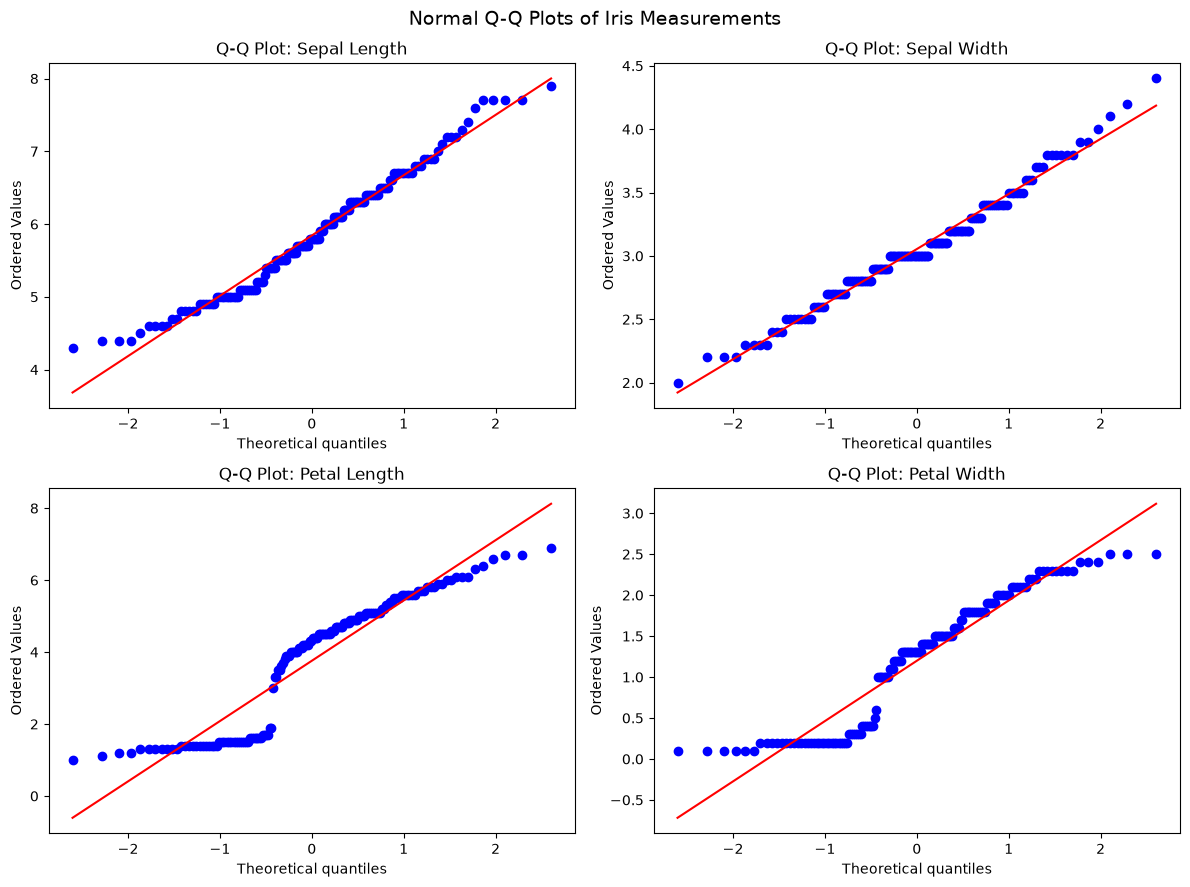

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, column in zip(axes.flatten(), numeric_columns):

    stats.probplot(
        df[column],
        dist="norm",
        plot=ax
    )

    ax.set_title(
        f"Q-Q Plot: {column.replace('_', ' ').title()}"
    )

plt.suptitle(
    "Normal Q-Q Plots of Iris Measurements",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Q-Q Plot Interpretation

The Q-Q plots support the earlier normality analysis.

- Sepal length follows the reference line reasonably well, suggesting an approximately normal distribution.
- Sepal width also follows the reference line fairly closely, although there are some deviations at the tails.
- Petal length shows clear departures from the reference line, indicating that its overall distribution is not normal.
- Petal width also shows noticeable departures from normality.

The non-normal patterns for petal length and petal width are likely influenced by combining measurements from three Iris species with distinctly different petal sizes.

## Correlation Significance Test

The Pearson correlation coefficient is used to measure the linear relationship between petal length and petal width.

**Null hypothesis (H₀):** There is no linear correlation between petal length and petal width.

**Alternative hypothesis (H₁):** There is a significant linear correlation between petal length and petal width.

A significance level of α = 0.05 is used.

In [44]:
pearson_r, pearson_p = stats.pearsonr(
    df["petal_length"],
    df["petal_width"]
)

print("Pearson correlation coefficient:",
      round(pearson_r, 4))

print("P-value:",
      pearson_p)

Pearson correlation coefficient: 0.9628
P-value: 5.7766609884951665e-86


### Correlation Interpretation

The Pearson correlation coefficient between petal length and petal width is 0.9628, indicating a very strong positive linear relationship.

The p-value is approximately 5.78 × 10⁻⁸⁶, which is much smaller than the significance level of 0.05. Therefore, we reject the null hypothesis of no linear correlation.

There is statistically significant evidence of a strong positive relationship between petal length and petal width. In general, Iris flowers with longer petals also tend to have wider petals.

Correlation describes association and does not by itself establish a causal relationship.